#Proyecto Python

## 🎯 Objetivo
El objetivo de este notebook es limpiar, validar y preparar el dataset de Kiva para su análisis posterior, asegurando la calidad, consistencia y trazabilidad de los datos.

## 📂 Dataset
- Fuente: Kiva Loans Dataset
- Variables principales: loan_amount, borrower_genders, country, term_in_months

## 🧠 Enfoque
Se realizará:
- Análisis exploratorio inicial
- Detección de problemas
- Limpieza y transformación
- Validación final

## 1. Importación de datos

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [8]:
df = pd.read_csv('kiva_loans.csv')

##2.Analisis exploratorio inicial

### 🧠 Observaciones iniciales
- Dataset con 15439 filas y 20 columnas
- Variables numéricas: loan_amount, term_in_months
- Presencia de variables categóricas: country, borrower_genders

In [9]:
#Cargar el dataset de kiva y visualizar los 4 primeros registros de la tabla.
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,tags,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,Fruits & Vegetables,Food,"To buy seasonal, fresh fruits to sell.",PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12.0,NaN,female,irregular,2014-01-01
1,653053,575.0,575.0,Rickshaw,Transportation,to repair and maintain the auto rickshaw used ...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14.0,NaN,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,Transportation,Transportation,To repair their old cycle-van and buy another ...,IN,India,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6.0,"user_favorite, user_favorite",female,bullet,2014-01-01
3,653063,200.0,200.0,Embroidery,Arts,to purchase an embroidery machine and a variet...,PK,Pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8.0,NaN,female,irregular,2014-01-01
4,653084,400.0,400.0,Milk Sales,Food,to purchase one buffalo.,PK,Pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16.0,NaN,female,monthly,2014-01-01


In [12]:
df.describe()
df.shape
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156308 entries, 0 to 156307
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  156308 non-null  int64  
 1   funded_amount       156308 non-null  float64
 2   loan_amount         156308 non-null  float64
 3   activity            156308 non-null  object 
 4   sector              156308 non-null  object 
 5   use                 154105 non-null  object 
 6   country_code        156308 non-null  object 
 7   country             156308 non-null  object 
 8   region              135858 non-null  object 
 9   currency            156307 non-null  object 
 10  partner_id          150365 non-null  float64
 11  posted_time         156307 non-null  object 
 12  disbursed_time      156042 non-null  object 
 13  funded_time         148421 non-null  object 
 14  term_in_months      156307 non-null  float64
 15  lender_count        156307 non-nul

##3.Limpieza y preparación de los datos

En esta fase se ha realizado un proceso de limpieza y transformación del dataset con el objetivo de garantizar la calidad, consistencia y usabilidad de los datos para su posterior análisis.

Se han llevado a cabo las siguientes acciones:

- Revisión de la estructura del dataset, tipos de variables y valores atípicos.
- Detección y tratamiento de valores nulos y duplicados.
- Corrección de formatos y estandarización de variables categóricas.
- Extracción de información relevante a partir de columnas complejas, como el desglose del campo `borrower_genders` en variables numéricas (`num_female` y `num_male`).
- Creación de nuevas variables derivadas, como la categorización del importe del préstamo (`loan_size`), para facilitar el análisis.



In [13]:
# Cambiar el tipo de dato de las variables 'disturbed_time' 'posted_time y 'funded_time' a datatime

datos = ['posted_time', 'disbursed_time', 'funded_time', 'date']
for col in datos:
  df[col] = pd.to_datetime(df[col], errors='coerce')

print('datos convertidos a fecha')
print(df[datos].dtypes)
df.info()


datos convertidos a fecha
posted_time       datetime64[ns, UTC]
disbursed_time    datetime64[ns, UTC]
funded_time       datetime64[ns, UTC]
date                   datetime64[ns]
dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156308 entries, 0 to 156307
Data columns (total 20 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  156308 non-null  int64              
 1   funded_amount       156308 non-null  float64            
 2   loan_amount         156308 non-null  float64            
 3   activity            156308 non-null  object             
 4   sector              156308 non-null  object             
 5   use                 154105 non-null  object             
 6   country_code        156308 non-null  object             
 7   country             156308 non-null  object             
 8   region              135858 non-null  object             
 9   currency  

In [14]:
# Chequear valores duplicados

df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop(columns=['tags'])

In [ ]:
df.head()

In [16]:
df.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,2203
country_code,0
country,0
region,20450
currency,1


In [17]:
# Tratamos los valores nulos de las variables 'region', 'use' con cadena de texto 'unknown' y la variable 'partner_id con valor numérico (-1)

df['region'] = df['region'].fillna('unknown')
df['use'] = df['use'].fillna('unknown')
df['borrower_genders'] = df['borrower_genders'].fillna('unknown')
df['partner_id'] = df['partner_id'].fillna(-1)
df.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country_code,0
country,0
region,0
currency,1


In [18]:
# Se eliminan los nulos en las columnas con pocos datos nulos

df = df.dropna(subset=['term_in_months'])
df = df.dropna(subset=['repayment_interval'])
df = df.dropna(subset=['lender_count'])
df = df.dropna(subset=['date'])
df.isnull().sum()

,0
id,0
funded_amount,0
loan_amount,0
activity,0
sector,0
use,0
country_code,0
country,0
region,0
currency,0


In [19]:
# limpieza de texto, mayúsculas, minúsculas en 'country', 'use', 'sector' y 'activity'

df['country'] = df['country'].str.strip().str.lower()
df['sector'] = df['sector'].str.strip().str.lower()
df['activity'] = df['activity'].str.strip().str.lower()
df['use'] = df['use'].str.strip().str.lower()
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,partner_id,posted_time,disbursed_time,funded_time,term_in_months,lender_count,borrower_genders,repayment_interval,date
0,653051,300.0,300.0,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,247.0,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12.0,12.0,female,irregular,2014-01-01
1,653053,575.0,575.0,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,247.0,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11.0,14.0,"female, female",irregular,2014-01-01
2,653068,150.0,150.0,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,334.0,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43.0,6.0,female,bullet,2014-01-01
3,653063,200.0,200.0,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,247.0,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11.0,8.0,female,irregular,2014-01-01
4,653084,400.0,400.0,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,245.0,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14.0,16.0,female,monthly,2014-01-01


In [ ]:
df.info()

In [20]:
# Se convierte el tipo de dato de float a int

df['funded_amount'] = df['funded_amount'].astype(int)
df['loan_amount'] = df['loan_amount'].astype(int)
df['term_in_months'] = df['term_in_months'].astype(int)
df['lender_count'] = df['lender_count'].astype(int)
df['partner_id'] = df['partner_id'].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156307 entries, 0 to 156306
Data columns (total 19 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  156307 non-null  int64              
 1   funded_amount       156307 non-null  int64              
 2   loan_amount         156307 non-null  int64              
 3   activity            156307 non-null  object             
 4   sector              156307 non-null  object             
 5   use                 156307 non-null  object             
 6   country_code        156307 non-null  object             
 7   country             156307 non-null  object             
 8   region              156307 non-null  object             
 9   currency            156307 non-null  object             
 10  partner_id          156307 non-null  int64              
 11  posted_time         156307 non-null  datetime64[ns, UTC]
 12  disbursed_time      1

In [22]:
#Se crea una columna para indicar el número total de prestatarios sin diferencia de género

df['total_borrowers'] = df['borrower_genders'].str.count(',') + 1
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,disbursed_time,funded_time,term_in_months,lender_count,borrower_genders,repayment_interval,date,num_female,num_male,total_borrowers
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,...,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12,12,female,irregular,2014-01-01,1,0,1
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,...,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11,14,"female, female",irregular,2014-01-01,2,0,2
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,...,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43,6,female,bullet,2014-01-01,1,0,1
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,...,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11,8,female,irregular,2014-01-01,1,0,1
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,...,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14,16,female,monthly,2014-01-01,1,0,1


In [21]:
# Se crea una columna para indicar el número de mujeres y otra para el número de hombres

df['num_female'] = df['borrower_genders'].apply(
    lambda x: x.split(', ').count('female') if isinstance(x, str) else 0
)

df['num_male'] = df['borrower_genders'].apply(
    lambda x: x.split(', ').count('male') if isinstance(x, str) else 0
)
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,posted_time,disbursed_time,funded_time,term_in_months,lender_count,borrower_genders,repayment_interval,date,num_female,num_male
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,...,2014-01-01 06:12:39+00:00,2013-12-17 08:00:00+00:00,2014-01-02 10:06:32+00:00,12,12,female,irregular,2014-01-01,1,0
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,...,2014-01-01 06:51:08+00:00,2013-12-17 08:00:00+00:00,2014-01-02 09:17:23+00:00,11,14,"female, female",irregular,2014-01-01,2,0
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,...,2014-01-01 09:58:07+00:00,2013-12-17 08:00:00+00:00,2014-01-01 16:01:36+00:00,43,6,female,bullet,2014-01-01,1,0
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,...,2014-01-01 08:03:11+00:00,2013-12-24 08:00:00+00:00,2014-01-01 13:00:00+00:00,11,8,female,irregular,2014-01-01,1,0
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,...,2014-01-01 11:53:19+00:00,2013-12-17 08:00:00+00:00,2014-01-01 19:18:51+00:00,14,16,female,monthly,2014-01-01,1,0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 156307 entries, 0 to 156306
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype              
---  ------              --------------   -----              
 0   id                  156307 non-null  int64              
 1   funded_amount       156307 non-null  int64              
 2   loan_amount         156307 non-null  int64              
 3   activity            156307 non-null  object             
 4   sector              156307 non-null  object             
 5   use                 156307 non-null  object             
 6   country_code        156307 non-null  object             
 7   country             156307 non-null  object             
 8   region              156307 non-null  object             
 9   currency            156307 non-null  object             
 10  partner_id          156307 non-null  int64              
 11  posted_time         156307 non-null  datetime64[ns, UTC]
 12  disbursed_time      1

In [24]:
#Se crea una nueva columna para filtrar por mes y año

df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,term_in_months,lender_count,borrower_genders,repayment_interval,date,num_female,num_male,total_borrowers,month,year
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,...,12,12,female,irregular,2014-01-01,1,0,1,1,2014
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,...,11,14,"female, female",irregular,2014-01-01,2,0,2,1,2014
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,...,43,6,female,bullet,2014-01-01,1,0,1,1,2014
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,...,11,8,female,irregular,2014-01-01,1,0,1,1,2014
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,...,14,16,female,monthly,2014-01-01,1,0,1,1,2014


In [25]:
# Se crea la categoría 'loan_size' para categorizar los préstamos en diferentes rangos por cantidad prestada

def classify_loan(x):
    if x < 500:
        return 'micro'
    elif x < 2000:
        return 'small'
    elif x < 5000:
        return 'medium'
    else:
        return 'large'

df['loan_size'] = df['loan_amount'].apply(classify_loan)

In [26]:
df.head()

,id,funded_amount,loan_amount,activity,sector,use,country_code,country,region,currency,...,lender_count,borrower_genders,repayment_interval,date,num_female,num_male,total_borrowers,month,year,loan_size
0,653051,300,300,fruits & vegetables,food,"to buy seasonal, fresh fruits to sell.",PK,pakistan,Lahore,PKR,...,12,female,irregular,2014-01-01,1,0,1,1,2014,micro
1,653053,575,575,rickshaw,transportation,to repair and maintain the auto rickshaw used ...,PK,pakistan,Lahore,PKR,...,14,"female, female",irregular,2014-01-01,2,0,2,1,2014,small
2,653068,150,150,transportation,transportation,to repair their old cycle-van and buy another ...,IN,india,Maynaguri,INR,...,6,female,bullet,2014-01-01,1,0,1,1,2014,micro
3,653063,200,200,embroidery,arts,to purchase an embroidery machine and a variet...,PK,pakistan,Lahore,PKR,...,8,female,irregular,2014-01-01,1,0,1,1,2014,micro
4,653084,400,400,milk sales,food,to purchase one buffalo.,PK,pakistan,Abdul Hakeem,PKR,...,16,female,monthly,2014-01-01,1,0,1,1,2014,micro


In [27]:
# Se verifican los resultados

df['loan_size'].value_counts()

,count
loan_size,
micro,72127
small,69760
medium,11773
large,2647


In [ ]:
df.head(50)

##4. Validación de datos


Tras el proceso de limpieza, se ha realizado una fase de validación con el objetivo de comprobar la coherencia y fiabilidad de los datos transformados.

Las principales comprobaciones realizadas han sido:

- **Agregaciones por grupos**: se han calculado métricas como suma, media y conteo sobre variables clave (`loan_amount`, `country`) para verificar que los resultados son consistentes con el dataset original.
- **Análisis de participación por género**: se ha validado la correcta construcción de las variables `num_female` y `num_male`, comprobando su coherencia tanto a nivel global como por grupos.
- **Distribución por país**: se han analizado los préstamos por país para identificar posibles inconsistencias o valores atípicos en la distribución.
- **Detección de outliers**: se ha realizado una validación visual mediante histogramas y boxplots para identificar valores extremos en `loan_amount`, confirmando la presencia de una distribución sesgada con cola larga.


In [28]:
# Se agrupan datos para calcular media, suma , y conteo por las variables 'country' y 'loan_amount'

df.groupby('country')['loan_amount'].agg(['mean', 'sum', 'count']).sort_values(by='mean')

,mean,sum,count
country,,,
nigeria,139.245088,269300,1934
liberia,261.974270,529450,2021
philippines,366.880638,12159525,33143
turkey,412.914692,87125,211
kenya,443.085844,7984850,18021
...,...,...,...
the democratic republic of the congo,5167.679128,3317650,642
panama,6000.000000,30000,5
congo,6018.820225,535675,89


In [29]:
# Se filtran los préstamos por participacion femenina y su distribución por país

df[df['borrower_genders'] == 'female'] \
  .groupby('country')['loan_amount'] \
  .sum() \
  .sort_values(ascending=False)

,loan_amount
country,
philippines,11138475
kenya,4167800
el salvador,4036775
tajikistan,2894675
united states,2782025
...,...
saint vincent and the grenadines,2025
solomon islands,2025
somalia,2000


In [46]:
# Para detectar outliers en nuestro dataset , incorporamos la formula de quartiles en la variable que percibimos que tiene valores extremos

Q1 = df['loan_amount'].quantile(0.25)
Q3 = df['loan_amount'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['loan_amount'] < Q1 - 1.5*IQR) |
              (df['loan_amount'] > Q3 + 1.5*IQR)]

In [47]:
# Imprime valores extremos min y max

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(lower, upper)

-812.5 2087.5


In [48]:
# Visualiza el numero de valores grandes en este caso, prestamos con valores extremos

len(outliers)

12891

##5. Visualización

Se han utilizado gráficos (boxplots y gráficos de barras) para analizar la distribución de los datos, identificar patrones y detectar valores atípicos, facilitando la interpretación y validación del dataset.

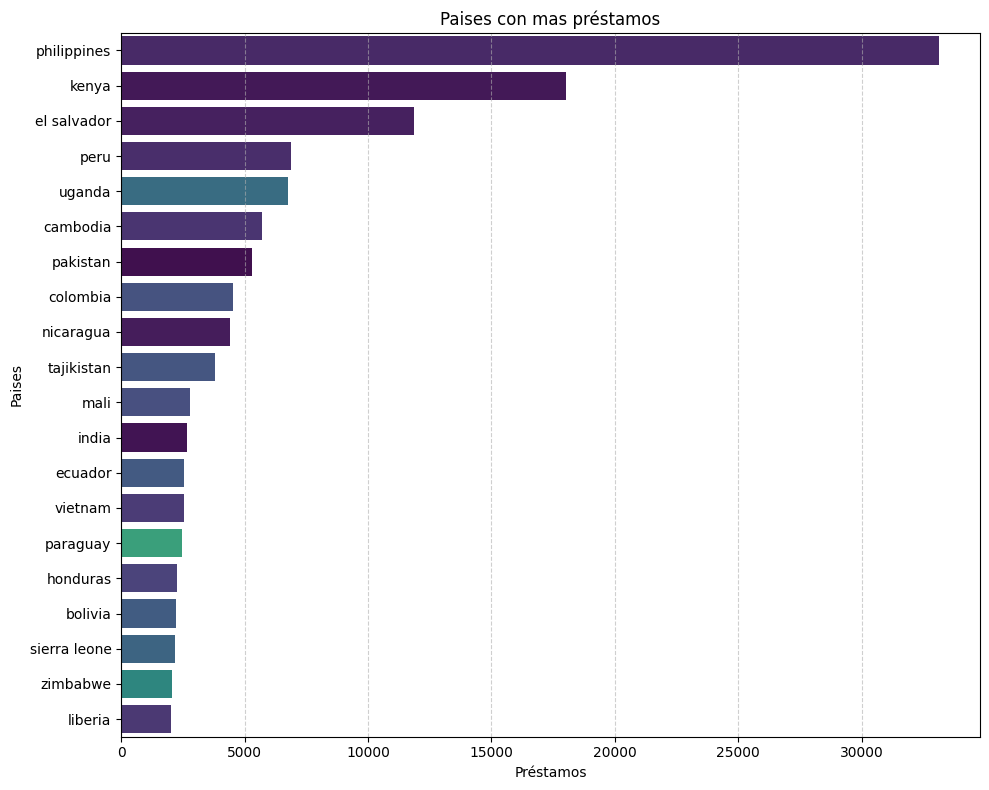

In [30]:
#Se incluye gráfico para visualizar los países con mas préstamos distribuidos.

top_paises = df['country'].value_counts().nlargest(20).index
camb = df[df['country'].isin(top_paises)]

fig, axes = plt.subplots(1, 1, figsize=(10, 8))

sns.countplot(data=df, y='country', ax=axes, palette='viridis', hue='country', legend=False, order=top_paises)
axes.set_title('Paises con mas préstamos')
axes.set_xlabel('Préstamos')
axes.set_ylabel('Paises')
axes.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

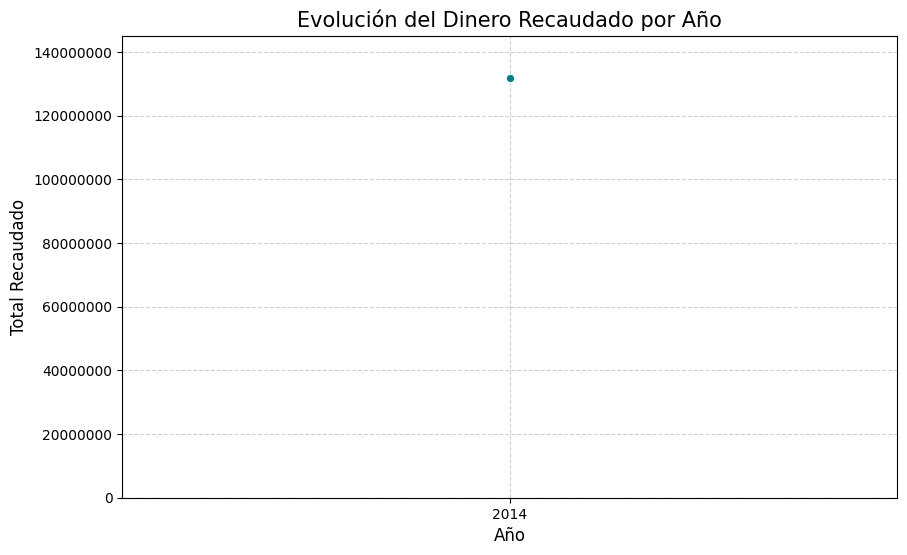

In [31]:
# Se añade un gráfico de línea para ver la evolución del dinero recaudado por año.

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

datos_por_year = df.groupby('year')['funded_amount'].sum().reset_index()

plt.figure(figsize=(10, 6))

sns.lineplot(data=datos_por_year, x='year', y='funded_amount', marker='o', color='teal', linewidth=2.5)

plt.xticks(datos_por_year['year'])

plt.title('Evolución del Dinero Recaudado por Año', fontsize=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Total Recaudado', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.ticklabel_format(style='plain', axis='y')
plt.ylim(0, datos_por_year['funded_amount'].max() * 1.1)

plt.show()

In [34]:
# Se crea un gráfico de barras para comparar hombres y mujeres por rango de préstamos

grouped = df.groupby('loan_size', observed=True)[['num_female', 'num_male']].sum().reset_index()

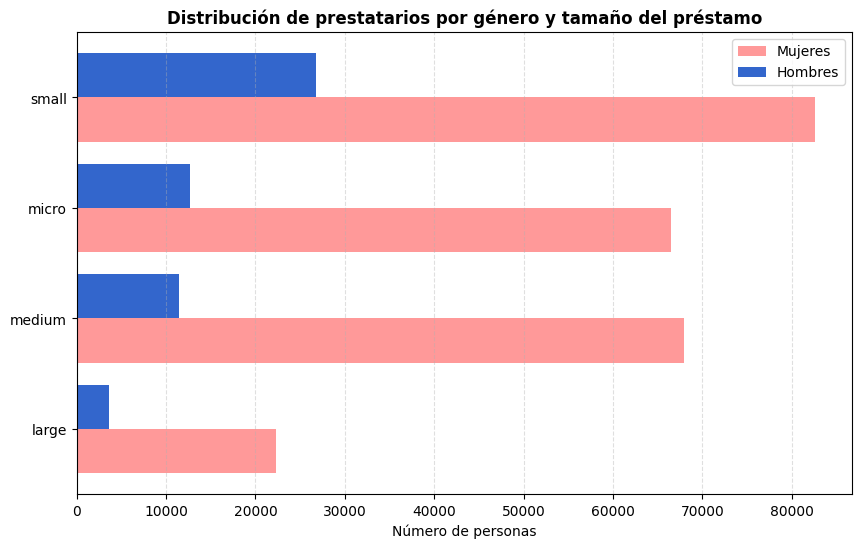

In [35]:
y = np.arange(len(grouped))
height = 0.4

plt.figure(figsize=(10,6))

plt.barh(y - height/2, grouped['num_female'], height, label='Mujeres', color='#ff9999')
plt.barh(y + height/2, grouped['num_male'], height, label='Hombres', color='#3366cc')

plt.yticks(y, grouped['loan_size'])
plt.xlabel('Número de personas')
plt.title('Distribución de prestatarios por género y tamaño del préstamo', fontweight='bold')

plt.legend()
plt.grid(axis='x', linestyle='--', alpha=0.4)


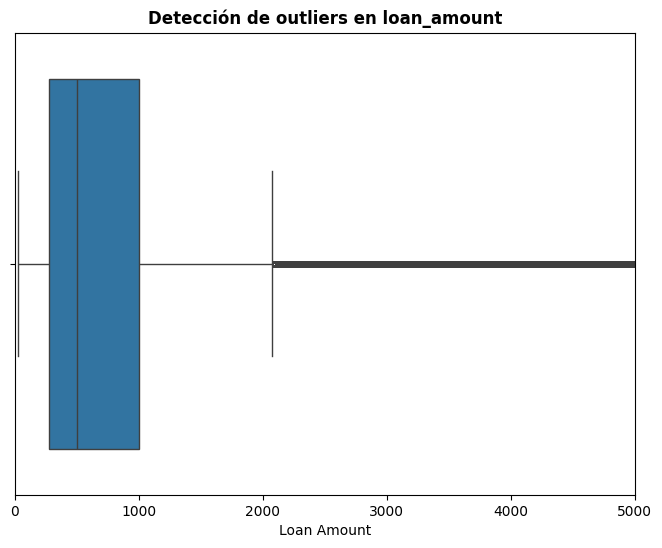

In [53]:
# Incluimos un gráfico de cajas o boxplot que muestre la distrubución de los datos de loan amount y valores extremos en la gráfica

plt.figure(figsize=(8,6))

sns.boxplot(
    x=df['loan_amount'],
    flierprops=dict(marker='o', markersize=4)
    )

plt.xlim(0, 5000)
plt.title('Detección de outliers en loan_amount', fontweight='bold')
plt.xlabel('Loan Amount')

plt.show()

##6. Conclusiones

- Existe un claro predominio de mujeres prestatarias
- El país con mas cantidad de préstamos distribuidos en Filipinas.
- La mayoría de los préstamos se concentran en rangos de microprestamos y prestamos pequeños.
- La distribución de la variable loan amount presenta una alta concentración de valores extremos.


**Decisiones tomadas**

- No se eliminaron outliers por representar valores reales
- Se generaron variables derivadas para análisis de género
- Se definieron rangos basados en percentiles del dataset